# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
#импортируем необходимые библиотеки
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

from math import ceil

from statsmodels.stats.proportion import proportions_ztest


In [2]:
df = pd.read_csv('/datasets/sessions_project_history.csv')
df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
groupped_data_user = df.groupby('user_id')['session_id'].count().sort_values()
print(groupped_data_user)
user_df = df[df['user_id'] == '6A73CB5566BB494D'] #выбираем последний user_id из выдачи - 6A73CB5566BB494D
user_df.head(10)

user_id
7694800965762974     1
D1A0321CA4E8AAE9     1
D1A0C8E79F9869B7     1
5ED90783E87435CC     1
41C694E8182BCCD2     1
                    ..
978581A8F7D74A74     9
E8ADFF2913E86056     9
32F90A8BA4D055CE     9
10E0DEFC1ABDBBE0    10
6A73CB5566BB494D    10
Name: session_id, Length: 134039, dtype: int64


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
124515,6A73CB5566BB494D,110E3F28C1F5415F,2025-08-28,2025-08-28 18:58:19,2025-08-28,1,0,3,MENA,Mac
196252,6A73CB5566BB494D,D68C8D98A0F1C439,2025-08-29,2025-08-29 20:53:27,2025-08-28,2,1,3,MENA,Mac
242428,6A73CB5566BB494D,6587D217472BF807,2025-08-30,2025-08-30 13:08:22,2025-08-28,3,1,1,MENA,Mac
304287,6A73CB5566BB494D,A9BC25593D056F8E,2025-09-01,2025-09-01 18:52:49,2025-08-28,4,1,2,MENA,Mac
346611,6A73CB5566BB494D,CB6F9C4191FAF6F6,2025-09-03,2025-09-03 22:49:08,2025-08-28,5,1,3,MENA,Mac
363510,6A73CB5566BB494D,9C609432F6E6535A,2025-09-04,2025-09-04 13:59:46,2025-08-28,6,1,4,MENA,Mac
391902,6A73CB5566BB494D,5D892E33B97A257A,2025-09-06,2025-09-06 18:46:55,2025-08-28,7,1,2,MENA,Mac
404322,6A73CB5566BB494D,22A9BD3861F49087,2025-09-07,2025-09-07 18:33:49,2025-08-28,8,1,3,MENA,Mac
415489,6A73CB5566BB494D,F70E351154B092DC,2025-09-08,2025-09-08 20:30:22,2025-08-28,9,1,4,MENA,Mac
425805,6A73CB5566BB494D,84A3DC0CFF449F53,2025-09-09,2025-09-09 16:36:04,2025-08-28,10,1,1,MENA,Mac


In [5]:
#проверим, верные ли типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


In [6]:
#скорректируем типы данных session_date, session_start_ts, install_date 
df['session_date'] = pd.to_datetime(df['session_date'])
df['session_start_ts'] = pd.to_datetime(df['session_start_ts'])
df['install_date'] = pd.to_datetime(df['install_date'])


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

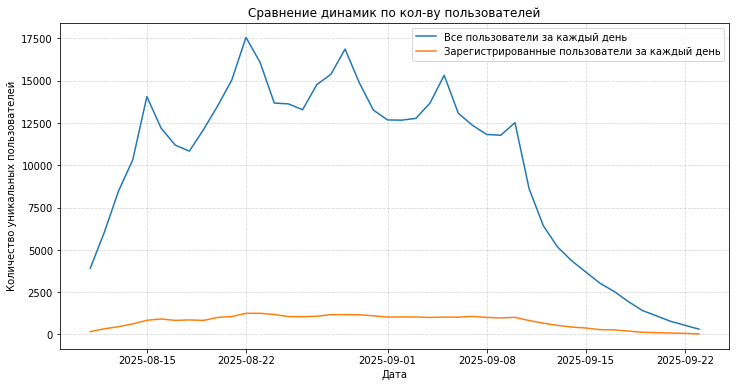

In [7]:
#считаем всех юзеров за каждый день
groupped_data_all_users = df.groupby('session_date')['user_id'].nunique()
#считаем зарегистрированных юзеров за каждый день
groupped_data_reg_users = df[df['registration_flag'] == 1].groupby('session_date')['user_id'].nunique()

#строим график
plt.figure(figsize=(12, 6))
plt.plot(groupped_data_all_users.index, groupped_data_all_users.values, label='Все пользователи за каждый день')
plt.plot(groupped_data_reg_users.index, groupped_data_reg_users.values, label='Зарегистрированные пользователи за каждый день')

plt.xlabel("Дата")
plt.ylabel("Количество уникальных пользователей")
plt.legend()
plt.title('Сравнение динамик по кол-ву пользователей')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

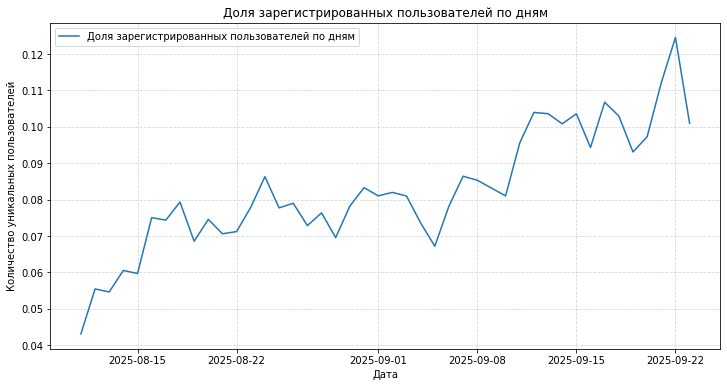

In [8]:
#считаем долю зарегистрированных юзеров
reg_users_ratio = groupped_data_reg_users / groupped_data_all_users
#строим график
plt.figure(figsize=(12, 6))
plt.plot(reg_users_ratio.index, reg_users_ratio.values, label='Доля зарегистрированных пользователей по дням')
plt.xlabel("Дата")
plt.ylabel("Количество уникальных пользователей")
plt.legend()
plt.title('Доля зарегистрированных пользователей по дням')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

page_counter
1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
dtype: int64


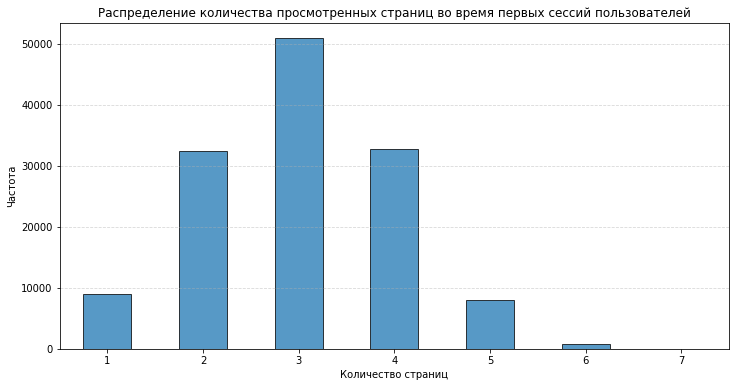

In [9]:
#считаем количество первых сессий для каждого значения количества просмотренных страниц
groupped_data_first_session = df[df['session_number'] == 1].groupby('page_counter').size()
print(groupped_data_first_session)

#строим график
plt.figure(figsize=(12, 6))


groupped_data_first_session.plot(
                kind='bar',  
                alpha=0.75,
                edgecolor='black',
)

plt.title('Распределение количества просмотренных страниц во время первых сессий пользователей')
plt.xlabel('Количество страниц')
plt.ylabel('Частота')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.show() 

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

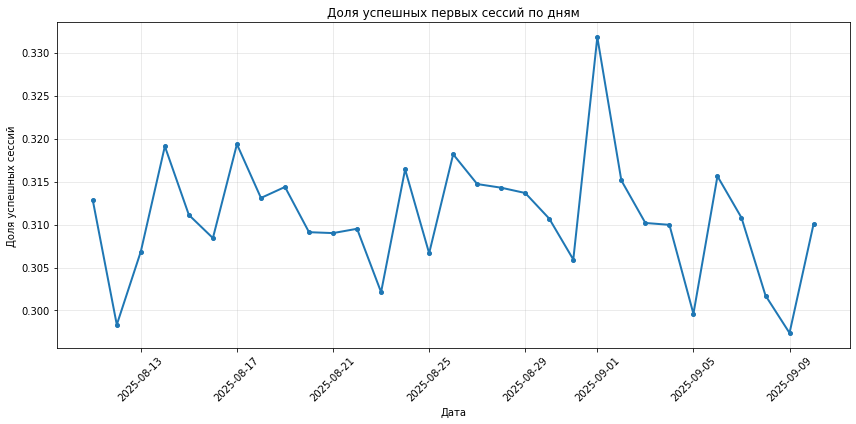

In [10]:
#создаем новый столбец
df['good_session'] = 0
df.loc[df['page_counter'] >= 4, 'good_session'] = 1

#считаем среднее значение доли первых сессий по дням
groupped_total_sessions = df[df['session_number'] == 1].groupby('session_date').size()
groupped_good_sessions = df[ (df['session_number'] == 1) & (df['good_session'] == 1)].groupby('session_date').size()
sessions_ratio = groupped_good_sessions / groupped_total_sessions
sessions_ratio_mean = sessions_ratio.mean()

plt.figure(figsize=(12, 6))
plt.plot(sessions_ratio.index, sessions_ratio.values, marker='o', linewidth=2, markersize=4)
plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [11]:

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли

#MDE как 3% от p
mde_relative_fraction = 0.03
mde = p * mde_relative_fraction
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [12]:

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = groupped_data_all_users.mean() #берем переменную, которую уже считали в задании 1.3. Анализ числа регистраций и находим ее ср. значение
sample_size_a_b = sample_size * 2


# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size_a_b/ avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [13]:
df_test = pd.read_csv('/datasets/sessions_project_test_part.csv')

#считаем кол-во уникальных юзеров в группах
group_a = df_test[df_test['test_group'] == 'A']['user_id'].nunique()
group_b = df_test[df_test['test_group'] == 'B']['user_id'].nunique()
print(group_a)
print(group_b)


#считаем процентную разницу по формуле:
percent_diff_a_b = 100 * ((abs(group_a - group_b)) / group_a)
print(percent_diff_a_b)


1477
1466
0.7447528774542992


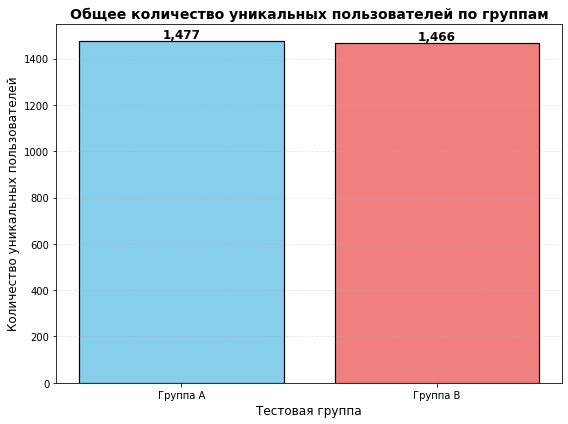

In [14]:
#строим график
groups = ['Группа A', 'Группа B']
values = [group_a, group_b]
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(8, 6))
bars = plt.bar(groups, values, color=colors, edgecolor='black', linewidth=1.2)

# Добавляем подписи значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height:,}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Общее количество уникальных пользователей по группам', fontsize=14, fontweight='bold')
plt.xlabel('Тестовая группа', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [15]:
test_a = df_test[df_test['test_group'] == 'A']['user_id']
test_b = df_test[df_test['test_group'] == 'B']['user_id']

intersection = list(set(test_a) & set(test_b))
print(intersection) 

[]


Никто из пользователей не попал одновременно в обе группы.

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [16]:
group_a_devices = (df_test[df_test['test_group'] == 'A'].groupby('device')['user_id'].nunique())
group_b_devices = (df_test[df_test['test_group'] == 'B'].groupby('device')['user_id'].nunique())

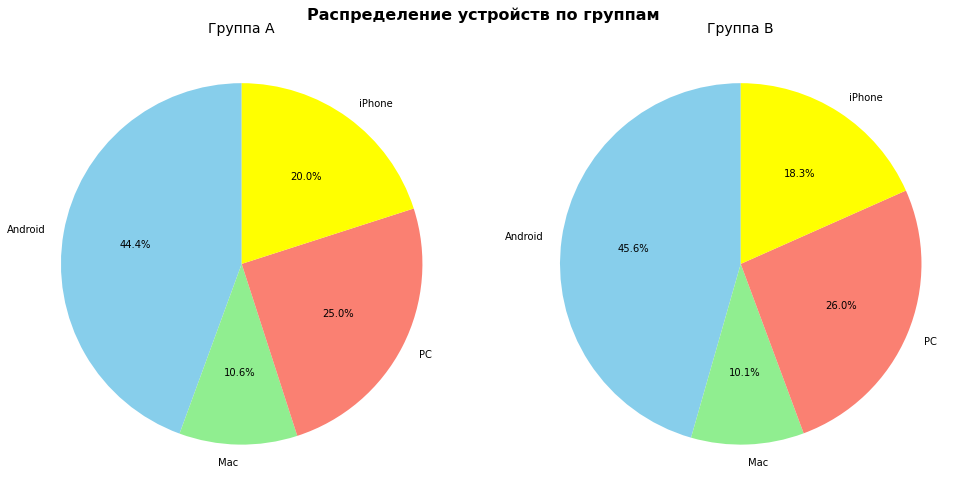

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

#диаграмма для группы A
ax1.pie(group_a_devices, labels=group_a_devices.index, autopct='%1.1f%%', startangle=90, 
        colors=['skyblue', 'lightgreen', 'salmon', 'yellow'])
ax1.set_title('Группа A', fontsize=14)

#диаграмма для группы B
ax2.pie(group_b_devices, labels=group_b_devices.index, autopct='%1.1f%%', startangle=90, 
        colors=['skyblue', 'lightgreen', 'salmon','yellow'])
ax2.set_title('Группа B', fontsize=14)

plt.suptitle('Распределение устройств по группам', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

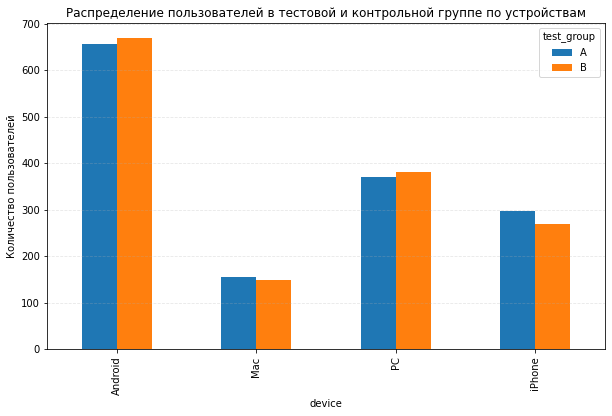

In [18]:
(df_test
 .groupby(['device', 'test_group'])['user_id']
 .nunique()
 .unstack()
 .plot(kind='bar', figsize=(10, 6), color={'A': '#1f77b4', 'B': '#ff7f0e'})
)

plt.title('Распределение пользователей в тестовой и контрольной группе по устройствам')
plt.xlabel('device')
plt.ylabel('Количество пользователей')
plt.legend(title='test_group')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [19]:
group_a_regions = (df_test[df_test['test_group'] == 'A'].groupby('region')['user_id'].nunique())
group_b_regions = (df_test[df_test['test_group'] == 'B'].groupby('region')['user_id'].nunique())

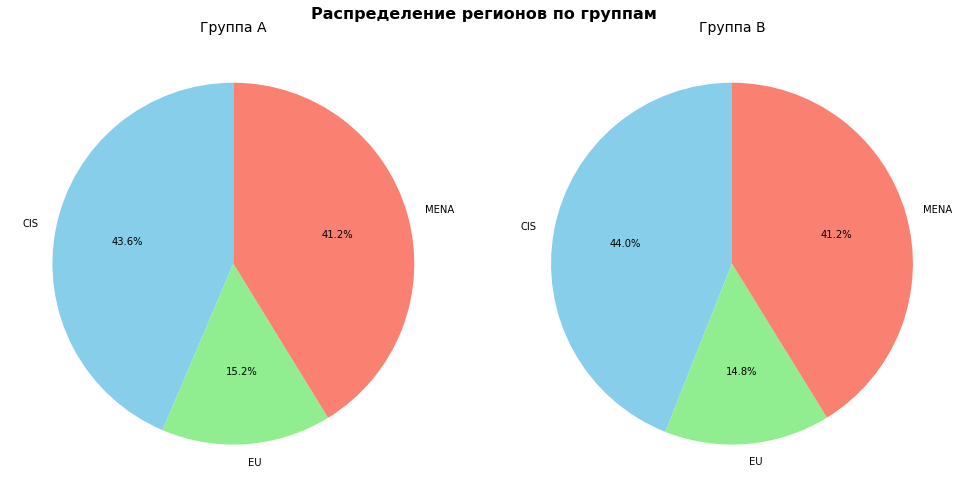

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

#диаграмма для группы A
ax1.pie(group_a_regions, labels=group_a_regions.index, autopct='%1.1f%%', startangle=90, 
        colors=['skyblue', 'lightgreen', 'salmon'])
ax1.set_title('Группа A', fontsize=14)

#диаграмма для группы B
ax2.pie(group_b_regions, labels=group_b_regions.index, autopct='%1.1f%%', startangle=90, 
        colors=['skyblue', 'lightgreen', 'salmon'])
ax2.set_title('Группа B', fontsize=14)

plt.suptitle('Распределение регионов по группам', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

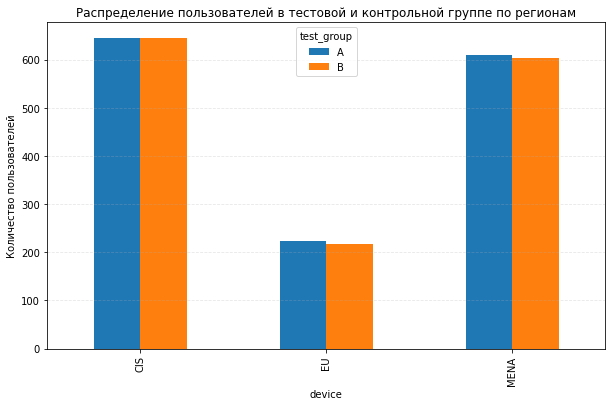

In [21]:
(df_test
 .groupby(['region', 'test_group'])['user_id']
 .nunique()
 .unstack()
 .plot(kind='bar', figsize=(10, 6), color={'A': '#1f77b4', 'B': '#ff7f0e'})
)

plt.title('Распределение пользователей в тестовой и контрольной группе по регионам')
plt.xlabel('device')
plt.ylabel('Количество пользователей')
plt.legend(title='test_group')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

Выводы:
1. Было обнаружено небольшое различие в кол-во пользователей в двух группах: 1477 vs 1466.
2. Выборки независимые, нет пользователей, которые находились бы одновременно в обеих группах.
3. Сохраняется равномерное распределение пользователей обеих групп по категориальным переменным: устройствам и регионам.
4. Тест проходит корректно.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [22]:
df_proj = pd.read_csv('/datasets/sessions_project_test.csv')
df_proj['good_session'] = 0
df_proj.loc[df_proj['page_counter'] >= 4, 'good_session'] = 1

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

Цель: проверить новый алгоритм рекомендаций, который, по мнению разрабочиков, будет показывать более интересный контент для каждого пользователя.<br>
Ключевая метрика: доля успешных первых сессий.<br>
Прокси-метрика: вовлеченность пользователей - сколько времени они проводят в приложении.<br>
Барьерная метрика: отсутствие технических инцидентов и жалоб пользователей на работу приложения.<br>
Нулевая гипотеза: доля успешных первых сессий не изменится.<br>
Альтернативная гипотеза: доля успешных первых сессий вырастет.


#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [23]:
total_sessions_a= df_proj[(df_proj['session_number']== 1) & (df_proj['test_group'] == 'A')].shape[0]
good_sessions_a= df_proj[(df_proj['session_number']== 1) & (df_proj['test_group']== 'A') & (df_proj['good_session']== 1)].shape[0]
sessions_ratio_a= round(good_sessions_a / total_sessions_a, 4)
print(f'Метрика a: {sessions_ratio_a}')

total_sessions_b= df_proj[(df_proj['session_number']== 1) & (df_proj['test_group'] == 'B')].shape[0]
good_sessions_b= df_proj[(df_proj['session_number']== 1) & (df_proj['test_group']== 'B') & (df_proj['good_session']== 1)].shape[0]
sessions_ratio_b= round(good_sessions_b / total_sessions_b, 4)
print(f'Метрика b: {sessions_ratio_b}')

#считаем абсолютную разницу между метриками
diff = round(abs(sessions_ratio_b - sessions_ratio_a),5)
diff_percent = round((abs(sessions_ratio_b - sessions_ratio_a)) * 100,5)
print(f'Абсолютная разница между метриками: {diff}')
print(f'Абсолютная разница между метриками в процентах: {diff_percent}')    

Метрика a: 0.3157
Метрика b: 0.3147
Абсолютная разница между метриками: 0.001
Абсолютная разница между метриками в процентах: 0.1


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [24]:
n_a = total_sessions_a
n_b = total_sessions_b
m_a = good_sessions_a
m_b = good_sessions_b


p_a, p_b = m_a/n_a, m_b/n_b # рассчитываем доли успехов для каждой группы: A и B

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha = 0.05 

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' # так как H_1: p_a > p_b
)

print(f'pvalue={p_value_ztest}') 

if p_value_ztest > alpha:
    print('Не удалось отвергнуть нулевую гипотезу')
else:
    print('Овергаем нулевую гипотезу')
    

Предпосылка о достаточном количестве данных выполняется!
pvalue=0.5783523649187868
Не удалось отвергнуть нулевую гипотезу


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

1. Ключевая метрика: доля успешных первых сессий. 
2. В эксперименте было задействовано:
- по плану 41040 пользователей в каждой группе, длительность 9 дней.
- по факту 30326 уникальных пользователей (по 15163 в каждой группе), длительность 20 дней.
3. Судя по статистическому тесту, внедрение нового алгоритма не привело к статистически значимым изменениям.
4. Р-value получилось 0.58, что больше уровня значимости в 0.05
5. Метрика a: 0.3157 <br>
Метрика b: 0.3147 <br> Разница между метриками: 0.1 %<br>
6. Нововведение внедрять не следует.

In [25]:
#считаем сколько по факту уникальных пользователей в тестовых данных
all_users_fact_group_a = df_proj[df_proj['test_group'] == 'A']['user_id'].nunique()
all_users_fact_group_b = df_proj[df_proj['test_group'] == 'A']['user_id'].nunique()
all_users_fact = all_users_fact_group_a + all_users_fact_group_b

print(f'Всего уникальных пользователей: {all_users_fact}')

#считаем длительность теста
df_proj['session_date'] = pd.to_datetime(df_proj['session_date'])
test_start = df_proj['session_date'].min()
test_end = df_proj['session_date'].max()
test_duration_days = (test_end - test_start).days + 1  #+1 чтобы включить обе границы
print(f'Длительность теста в днях: {test_duration_days}')

Всего уникальных пользователей: 30326
Длительность теста в днях: 20
